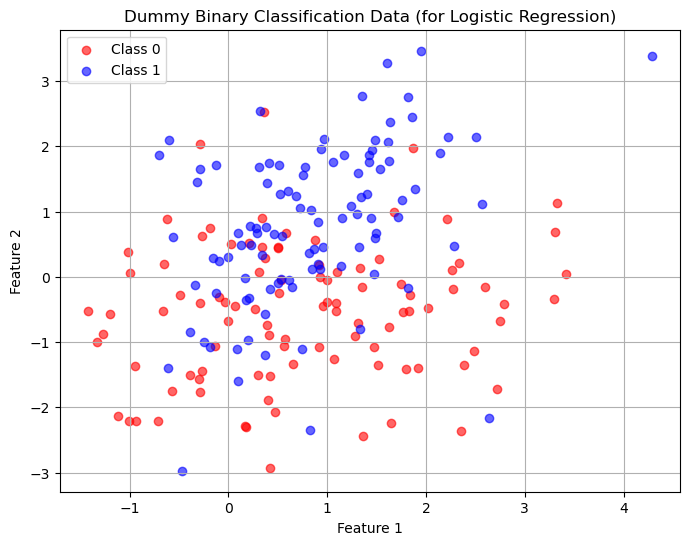

Features shape: (200, 2)
Target shape: (200,)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [4]:
w=np.random.rand(1,2)
b=np.array([[0]])
cost_history=[]
y_train=y.reshape(-1,1)
print(y.shape,w.shape,x.shape,y_train.shape)
m=x.shape[0]
learning_rate=0.01
mean=np.mean(x,axis=0)
std=np.std(x,axis=0)
x=(x-mean)/std

(200,) (1, 2) (200, 2) (200, 1)


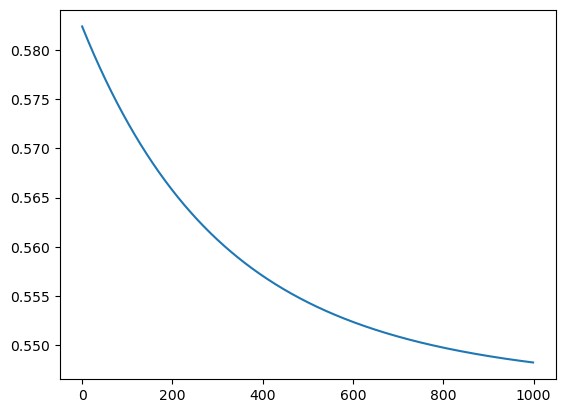

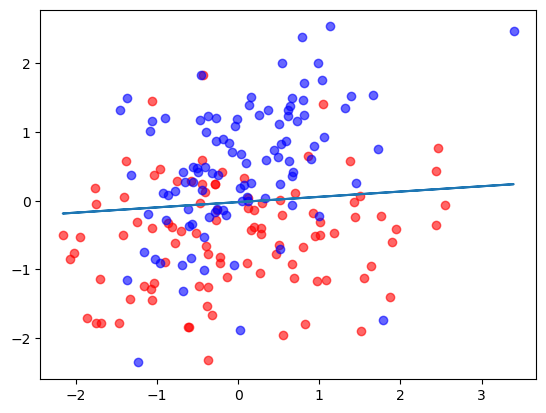

In [5]:
for i in range(1000):
   z=(x @ w.T) + b
   yy=1/(1+(np.exp(-z)))
   cost=np.mean(-(y_train*(np.log(yy+0.000000001)))-(1-y_train)*(np.log(1-yy+0.000000001)))
   cost_history.append(cost)
   djdw=(x.T @ (yy-y_train)).T / m
   djdb=(np.sum(yy-y_train))/m
   w=w-(learning_rate*djdw)
   b=b-(learning_rate*djdb)
    
plt.plot(cost_history)
plt.show()
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)

x1 = x[:, 0]
x2 = (-w[0][0]*x1-b[0][0])/w[0][1]
plt.plot(x1,x2)

plt.show()

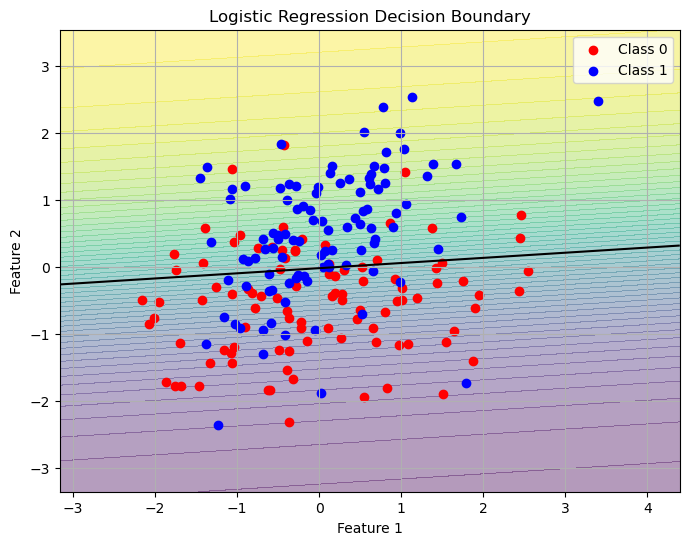

In [7]:
# Create mesh grid
x1_min, x1_max = x[:,0].min()-1, x[:,0].max()+1
x2_min, x2_max = x[:,1].min()-1, x[:,1].max()+1

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

# Convert grid into points
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

# Prediction on grid
z = (grid_points @ w.T) + b
pred = 1 / (1 + np.exp(-z))

# Reshape predictions
pred = pred.reshape(xx1.shape)

# Plot decision regions
plt.figure(figsize=(8,6))

plt.contourf(xx1, xx2, pred, levels=50, alpha=0.4)

# Plot data points
plt.scatter(
    x[y == 0][:,0],
    x[y == 0][:,1],
    color="red",
    label="Class 0"
)

plt.scatter(
    x[y == 1][:,0],
    x[y == 1][:,1],
    color="blue",
    label="Class 1"
)

# Decision boundary
plt.contour(xx1, xx2, pred, levels=[0.5], colors="black")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()